# EDA & Tiền xử lý — Communities and Crime (`communities.data`)

Bài toán **hồi quy**: dự đoán `ViolentCrimesPerPop` (tỉ lệ tội phạm bạo lực, đã chuẩn hoá [0,1]).
Bộ này **128 cột, gần như toàn số** → rất hợp thực nghiệm **feature selection trên Linear Regression**
(nhiều feature, có cả feature yếu/nhiễu). Đặc thù: file `.data` **không có header** (lấy tên cột từ `.names`),
missing ký hiệu bằng **`?`**, có vài cột định danh và nhiều cột thiếu rất nặng.

> ℹ️ Bộ này **toàn biến số** → **không có one-hot/encoding** để đổi; thay đổi "binary mapping" chỉ áp dụng cho bộ
> Obesity. Ở đây trọng tâm là **làm sạch + EDA chi tiết**. ⚠️ Target giữ **nguyên gốc**, chỉ xử lý feature.

## 0. Thiết lập môi trường
**Lý do:** Xử lý trực tiếp trên **dữ liệu gốc** `communities.data`. Trên Colab **tự mount Drive**; `find_data_dir`
tự dò thư mục chứa `communities+and+crime/`. 👉 Nếu auto-detect thất bại, sửa **`DATA_DIR`** thành đường dẫn của bạn.

In [1]:
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Tu dong mount Google Drive neu chay tren Colab
try:
    import google.colab  # noqa
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
except ImportError:
    pass

# >>> Neu auto-detect that bai: dat DATA_DIR = duong dan thu muc chua 'communities+and+crime' <<<
DATA_DIR = None

def find_data_dir(marker, override=None):
    cands = ([override] if override else []) + [
        'dataset', 'Data/dataset', '.', '..',
        '/content/drive/MyDrive/AIO-Conquer02',
        '/content/drive/MyDrive/conquer1/AIO-Conquer-Data/Data/dataset',
    ]
    for p in cands:
        if p and os.path.exists(os.path.join(p, marker)):
            return p
    raise FileNotFoundError("Khong tim thay '" + marker + "'. Hay dat DATA_DIR = duong dan thu muc chua file nay.")

DATA_DIR = find_data_dir('communities+and+crime', DATA_DIR)
BASE = os.path.join(DATA_DIR, 'communities+and+crime')
print('BASE =', BASE)

# Thu muc luu hinh EDA (savefig se ghi PNG vao day de bao cao lay lai)
ASSETS_DIR = next((p for p in ['eda_assets', 'Data/eda_assets', '../eda_assets'] if os.path.isdir(p)), 'eda_assets')
os.makedirs(ASSETS_DIR, exist_ok=True)
print('ASSETS_DIR =', os.path.abspath(ASSETS_DIR))

Mounted at /content/drive
BASE = /content/drive/MyDrive/AIO-Conquer02/communities+and+crime
ASSETS_DIR = /content/eda_assets


## 1. Nạp dữ liệu — lấy tên cột từ `.names`

**Lý do:** `communities.data` không có header; tên 128 cột nằm trong các dòng `@attribute` của `communities.names`.
Đọc kèm `na_values='?'` để pandas hiểu ô thiếu.

In [2]:
names = []
with open(os.path.join(BASE, 'communities.names'), encoding='latin-1') as f:
    for line in f:
        m = re.match(r'@attribute\s+(\S+)\s+(\S+)', line.strip(), re.I)
        if m:
            names.append(m.group(1))
print('So cot doc duoc tu .names:', len(names))

df = pd.read_csv(os.path.join(BASE, 'communities.data'), header=None, names=names, na_values='?')
df.info(verbose=False)
print('Target:', names[-1])

So cot doc duoc tu .names: 128
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Columns: 128 entries, state to ViolentCrimesPerPop
dtypes: float64(125), int64(2), object(1)
memory usage: 1.9+ MB
Target: ViolentCrimesPerPop


> 📊 **Phân tích:** **1.994 dòng × 128 cột**, gần như toàn `float64` (đã chuẩn hoá [0,1]); chỉ `communityname` là chuỗi.
> Target `ViolentCrimesPerPop` (cột cuối). 5 cột đầu là **định danh/không dự đoán**: `state`, `county`, `community`,
> `communityname`, `fold` (cột `fold` chỉ là chỉ số chia CV).

## 2. Cleaning bước 1 — bỏ cột định danh

**Lý do:** `state`, `county`, `community`, `communityname`, `fold` là định danh hành chính / chỉ số fold,
không phải đặc trưng dự đoán → bỏ để tránh nhiễu cho selection.

In [3]:
id_cols = ['state', 'county', 'community', 'communityname', 'fold']
df = df.drop(columns=[c for c in id_cols if c in df.columns])
print('Sau khi bo dinh danh:', df.shape)

Sau khi bo dinh danh: (1994, 123)


> 📊 **Phân tích:** Còn **123 cột** (122 feature + target). Tất cả còn lại đều là biến số đã chuẩn hoá.

## 3. Phân tích missing

**Lý do:** Bộ này thiếu rất nặng và **lệch hẳn về một nhóm cột** → đo tỉ lệ thiếu để quyết bỏ cột hay điền.

So cot co missing: 23
So cot thieu > 50%: 22


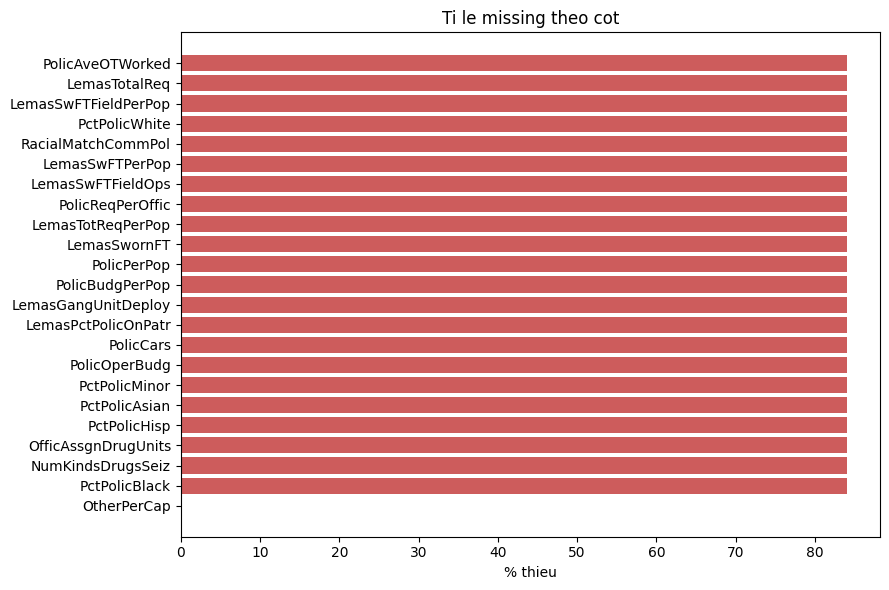

,pct_missing
PolicAveOTWorked,84.0
LemasTotalReq,84.0
LemasSwFTFieldPerPop,84.0
PctPolicWhite,84.0
RacialMatchCommPol,84.0
LemasSwFTPerPop,84.0
LemasSwFTFieldOps,84.0
PolicReqPerOffic,84.0
LemasTotReqPerPop,84.0
LemasSwornFT,84.0


In [4]:
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
print('So cot co missing:', len(miss))
print('So cot thieu > 50%:', int((miss > 0.5).sum()))
plt.figure(figsize=(9, 6))
plt.barh(miss.index[::-1], (miss * 100)[::-1], color='indianred')
plt.xlabel('% thieu'); plt.title('Ti le missing theo cot'); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'cm_missing.png'), dpi=150, bbox_inches='tight'); plt.show()
(miss * 100).round(1).to_frame('pct_missing')

> 📊 **Phân tích:** **23 cột có missing**, trong đó **22 cột thiếu >50%** — thực chất ~**84%** (1.675/1.994), gần như
> toàn nhóm chỉ số cảnh sát (`LemasSwornFT`, `PolicPerPop`, `PolicBudgPerPop`, `RacialMatchCommPol`...). Điền cho cột
> thiếu 84% là **bịa dữ liệu** → **bỏ hẳn**. Còn lại chỉ `OtherPerCap` thiếu **1 ô** → điền median. Target **không thiếu**.

## 4. Cleaning bước 2 — bỏ cột thiếu nặng & điền phần thiếu lẻ

**Lý do:** Bỏ cột thiếu >50% (không cứu được), điền median cho phần thiếu nhỏ (robust với lệch). **Không** đụng target.

In [5]:
TARGET = 'ViolentCrimesPerPop'
hi_missing = [c for c in df.columns if df[c].isna().mean() > 0.5]
df_clean = df.drop(columns=hi_missing)
feat = [c for c in df_clean.columns if c != TARGET]
df_clean[feat] = df_clean[feat].fillna(df_clean[feat].median())
print('Da bo', len(hi_missing), 'cot thieu >50%')
print('Shape sau cleaning:', df_clean.shape, '| missing con:', int(df_clean.isna().sum().sum()))

Da bo 22 cot thieu >50%
Shape sau cleaning: (1994, 101) | missing con: 0


> 📊 **Phân tích:** Còn **1.994 × 101** (100 feature + target), **0 missing**. Bộ đặc trưng giờ gọn, toàn số chuẩn hoá [0,1].

## 5. Phân phối target & độ lệch feature

**Lý do:** Xem hình dạng target và các feature lệch nhất.

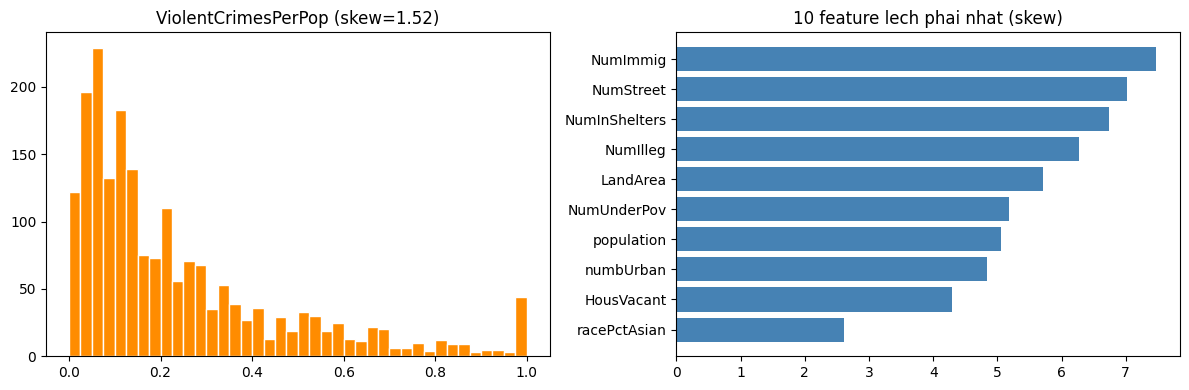

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df_clean[TARGET], bins=40, color='darkorange', edgecolor='white')
ax[0].set_title(TARGET + ' (skew=' + str(round(df_clean[TARGET].skew(),2)) + ')')
sk = df_clean.drop(columns=[TARGET]).skew().sort_values(ascending=False)
ax[1].barh(sk.index[:10][::-1], sk.values[:10][::-1], color='steelblue')
ax[1].set_title('10 feature lech phai nhat (skew)')
plt.tight_layout(); plt.show()

> 📊 **Phân tích:** Target **lệch phải (skew≈1,52)** — nhiều cộng đồng tội phạm thấp, đuôi cao thưa. Vì mọi biến đã
> **chuẩn hoá [0,1]** nên không cần scale lại; một số feature vẫn lệch nhưng nằm trong [0,1] nên ảnh hưởng nhẹ.

## 6. Tương quan với target

**Lý do:** Xếp hạng |Pearson| để xem feature nào mạnh, và quan trọng cho thí nghiệm: có bao nhiêu feature **yếu/gần nhiễu**.

Top 10 |corr| manh nhat:
PctKids2Par        -0.738
PctIlleg            0.738
PctFam2Par         -0.707
racePctWhite       -0.685
PctYoungKids2Par   -0.666
PctTeen2Par        -0.662
racepctblack        0.631
pctWInvInc         -0.576
pctWPubAsst         0.575
FemalePctDiv        0.556
Name: ViolentCrimesPerPop, dtype: float64

So feature |corr| < 0.1 (yeu, gan nhieu): 18 / 100


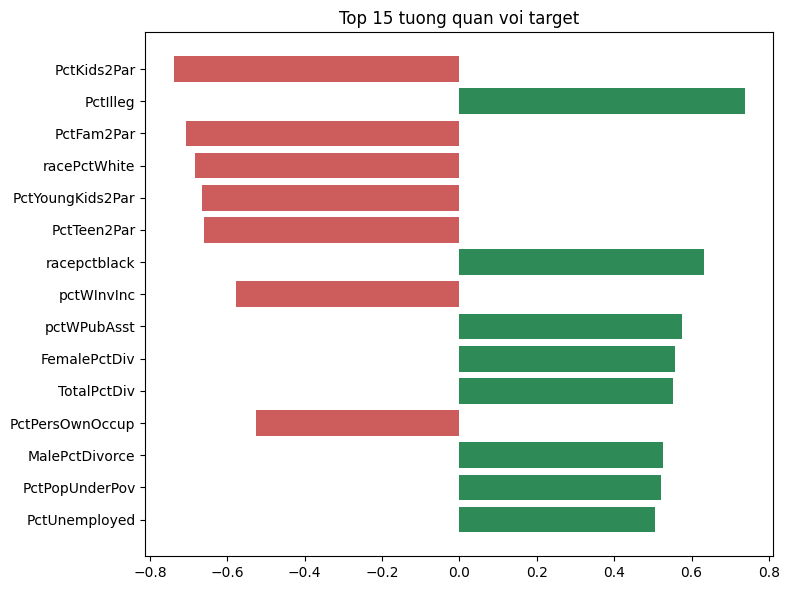

In [7]:
corr_t = df_clean.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
print('Top 10 |corr| manh nhat:')
print(corr_t.head(10).round(3))
print('\nSo feature |corr| < 0.1 (yeu, gan nhieu):', int((corr_t.abs() < 0.1).sum()), '/', len(corr_t))
plt.figure(figsize=(8, 6))
top = corr_t.head(15)
plt.barh(top.index[::-1], top.values[::-1], color=['seagreen' if v>0 else 'indianred' for v in top.values[::-1]])
plt.title('Top 15 tuong quan voi target'); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'cm_target_corr.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** Mạnh nhất: **`PctKids2Par` (−0,74)**, **`PctIlleg` (0,74)**, `PctFam2Par` (−0,71),
> `racePctWhite` (−0,69), `PctYoungKids2Par` (−0,67) — **cấu trúc gia đình & nhân khẩu**. Đáng chú ý cho thí nghiệm:
> **18/100 feature có |corr|<0,1** (yếu, gần nhiễu) → phần selection có thể loại để giúp Linear Regression.
> → **bộ này rất hợp** để đo impact của Lasso/Boruta/RFE.

## 7. Đa cộng tuyến giữa feature (bổ sung EDA)

**Lý do:** Nhiều cặp nhân khẩu/gia đình rất gần nhau → đếm số cặp |corr|>0,9 để cảnh báo đa cộng tuyến cho Linear Regression.

In [8]:
cm = df_clean.drop(columns=[TARGET]).corr().abs()
upper = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
pairs = (upper.stack().sort_values(ascending=False))
high = pairs[pairs > 0.9]
print('So cap feature |corr|>0.9:', len(high))
print(high.head(10).round(3))

So cap feature |corr|>0.9: 49
PctRecImmig8     PctRecImmig10        0.996
OwnOccLowQuart   OwnOccMedVal         0.994
PctRecImmig5     PctRecImmig8         0.993
population       numbUrban            0.993
OwnOccMedVal     OwnOccHiQuart        0.991
PctRecentImmig   PctRecImmig5         0.989
RentMedian       MedRent              0.989
PctRecImmig5     PctRecImmig10        0.986
PctFam2Par       PctKids2Par          0.985
PctLargHouseFam  PctLargHouseOccup    0.984
dtype: float64


> 📊 **Phân tích:** Tồn tại **nhiều cặp feature gần trùng** (vd các biến `*2Par`, `*PctWhite/Black`, thu nhập).
> Đa cộng tuyến làm hệ số Linear Regression bất ổn → càng cho thấy **giá trị của feature selection / regularization (Lasso)**.

## 8. Lưu dữ liệu đã xử lý

**Lý do:** Xuất bộ sạch: bỏ định danh + cột thiếu nặng, điền phần thiếu lẻ, giữ target nguyên gốc. Lưu `communities_processed.csv`.

In [9]:
out = os.path.join(DATA_DIR, 'communities_processed.csv')
df_clean.to_csv(out, index=False)
print('Da luu', out, '|', df_clean.shape, '| missing:', int(df_clean.isna().sum().sum()))
df_clean.head()

Da luu /content/drive/MyDrive/AIO-Conquer02/communities_processed.csv | (1994, 101) | missing: 0


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03


> 💾 **Kết quả:** `communities_processed.csv` — **1.994 × 101** (100 feature + target), 0 missing, feature ∈ [0,1], target nguyên gốc.
>
> **Sẵn cho thí nghiệm selection:** 100 feature số, ~18 feature yếu/nhiễu + nhiều cặp đa cộng tuyến → so sánh
> **Linear Regression full vs Lasso vs Boruta/RFE** (đo R² test + số feature giữ lại). Feature đã chuẩn hoá nhưng vẫn nên
> `StandardScaler` cho Lasso để phạt công bằng.